# Food Waste Reduction using Predictive Analytics
## Exploratory Data Analysis (EDA) Tutorial

**Objective:** Understand the store demand forecasting dataset before building predictive models.

**Dataset:** Store Item Demand Forecasting from Kaggle
- **Train Data:** Daily sales from 2013-2017 for 50 items across 10 stores
- **Test Data:** 90 days of 2018 to predict
- **Goal:** Predict future demand to reduce food waste from overstocking

---
## STEP 1: Import Libraries & Load Data

In [3]:
# Essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [4]:
# Load the training data
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

print("✓ Data loaded successfully")
print(f"\nTrain shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

✓ Data loaded successfully

Train shape: (913000, 4)
Test shape: (45000, 4)


---
## STEP 2: First Look at Data (Head, Info, Basic Stats)

In [5]:
# Display first few rows
print("FIRST 10 ROWS:")
print(df_train.head(10))
print("\n" + "="*50)

# Data types and info
print("\nDATA TYPES & INFO:")
df_train.info()

FIRST 10 ROWS:
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10
5  2013-01-06      1     1     12
6  2013-01-07      1     1     10
7  2013-01-08      1     1      9
8  2013-01-09      1     1     12
9  2013-01-10      1     1      9


DATA TYPES & INFO:
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [6]:
# Basic statistics
print("BASIC STATISTICS:")
print(df_train.describe())
print("\n" + "="*50)

# Key numbers to understand the data
print(f"\nKEY INSIGHTS:")
print(f"Date range: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"Number of unique stores: {df_train['store'].nunique()}")
print(f"Number of unique items: {df_train['item'].nunique()}")
print(f"Total records: {len(df_train)}")
print(f"\nAverage daily sales: {df_train['sales'].mean():.2f} units")
print(f"Min sales: {df_train['sales'].min()}, Max sales: {df_train['sales'].max()}")

BASIC STATISTICS:
               store           item          sales
count  913000.000000  913000.000000  913000.000000
mean        5.500000      25.500000      52.250287
std         2.872283      14.430878      28.801144
min         1.000000       1.000000       0.000000
25%         3.000000      13.000000      30.000000
50%         5.500000      25.500000      47.000000
75%         8.000000      38.000000      70.000000
max        10.000000      50.000000     231.000000


KEY INSIGHTS:
Date range: 2013-01-01 to 2017-12-31
Number of unique stores: 10
Number of unique items: 50
Total records: 913000

Average daily sales: 52.25 units
Min sales: 0, Max sales: 231


---
## STEP 3: Check for Missing Values

In [7]:
# Check missing values
print("MISSING VALUES:")
missing = df_train.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\n✓ No missing values! Dataset is clean.")
else:
    print(f"\n⚠ Found {missing.sum()} missing values to handle")

MISSING VALUES:
date     0
store    0
item     0
sales    0
dtype: int64

✓ No missing values! Dataset is clean.


---
## STEP 4: Convert Date to DateTime & Create Time Features

In [8]:
# Convert date to datetime
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

# Create useful time features
df_train['year'] = df_train['date'].dt.year
df_train['month'] = df_train['date'].dt.month
df_train['day'] = df_train['date'].dt.day
df_train['dayofweek'] = df_train['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_train['quarter'] = df_train['date'].dt.quarter
df_train['week'] = df_train['date'].dt.isocalendar().week

# Create labels for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_train['day_name'] = df_train['dayofweek'].map(lambda x: day_names[x])

print("✓ Time features created")
print("\nSample with new features:")
print(df_train[['date', 'year', 'month', 'dayofweek', 'day_name', 'store', 'item', 'sales']].head(10))

✓ Time features created

Sample with new features:
        date  year  month  dayofweek   day_name  store  item  sales
0 2013-01-01  2013      1          1    Tuesday      1     1     13
1 2013-01-02  2013      1          2  Wednesday      1     1     11
2 2013-01-03  2013      1          3   Thursday      1     1     14
3 2013-01-04  2013      1          4     Friday      1     1     13
4 2013-01-05  2013      1          5   Saturday      1     1     10
5 2013-01-06  2013      1          6     Sunday      1     1     12
6 2013-01-07  2013      1          0     Monday      1     1     10
7 2013-01-08  2013      1          1    Tuesday      1     1      9
8 2013-01-09  2013      1          2  Wednesday      1     1     12
9 2013-01-10  2013      1          3   Thursday      1     1      9


---
## STEP 5: Explore Sales Distribution

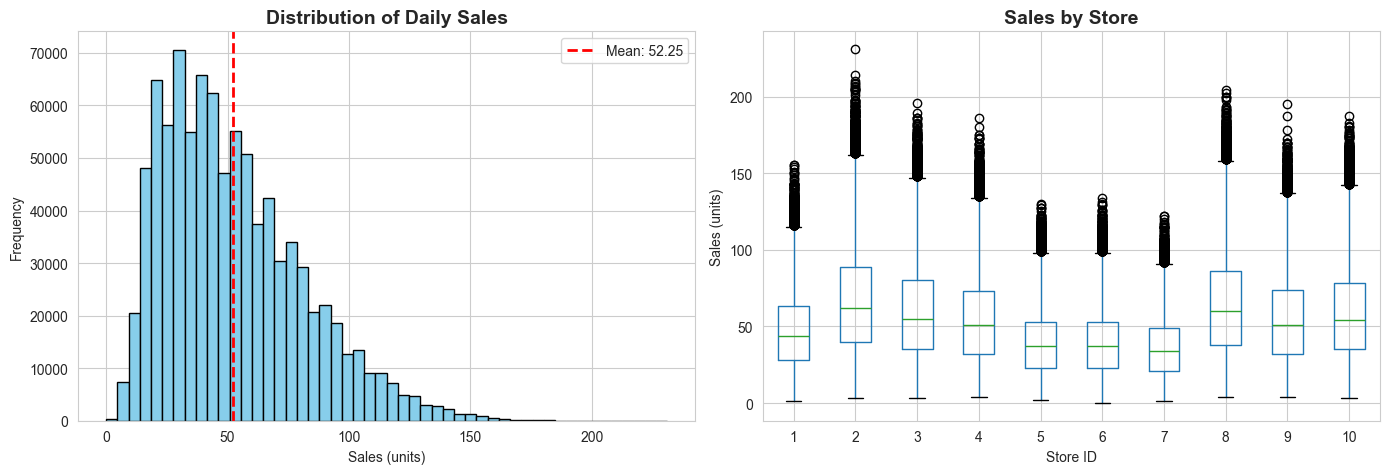

INSIGHT: Look at the distribution above. Is it normal? Are there outliers?


In [9]:
# Sales distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_train['sales'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Daily Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales (units)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_train['sales'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_train["sales"].mean():.2f}')
axes[0].legend()

# Box plot by store
df_train.boxplot(column='sales', by='store', ax=axes[1])
axes[1].set_title('Sales by Store', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Store ID')
axes[1].set_ylabel('Sales (units)')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

print("INSIGHT: Look at the distribution above. Is it normal? Are there outliers?")

---
## STEP 6: Time Series Trend - Sales Over Time

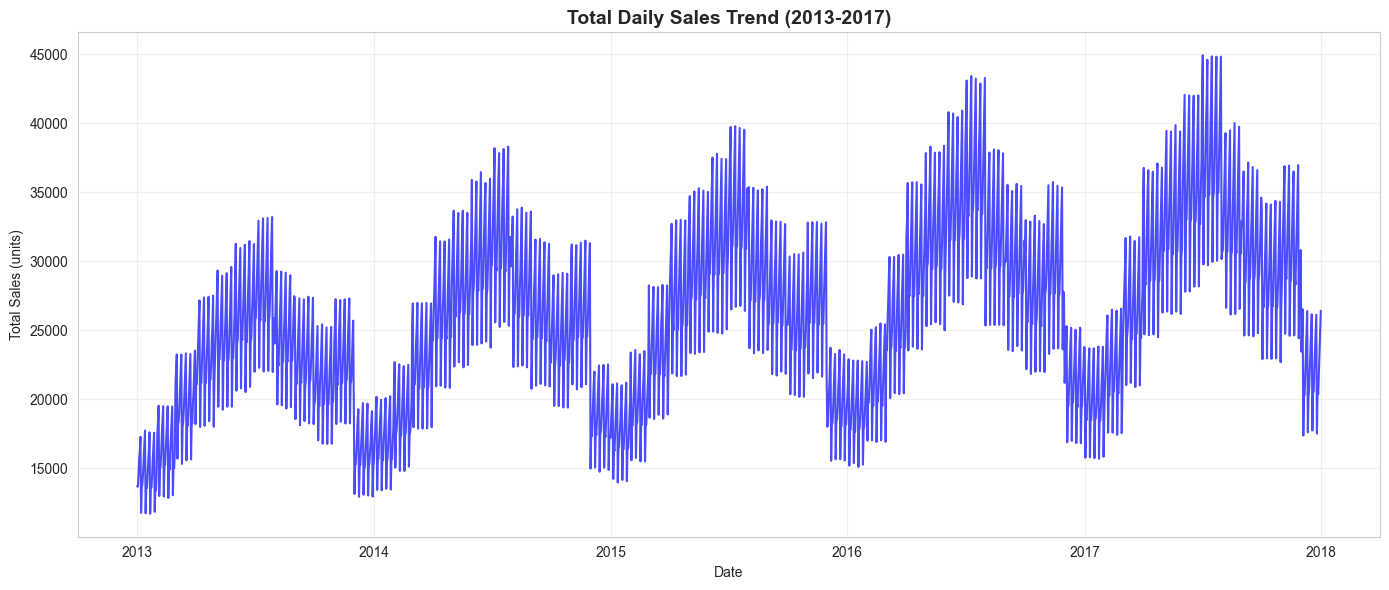

INSIGHT: Do you see any trends? Is sales increasing/decreasing over time?
Average daily sales: 26125 units


In [10]:
# Aggregate sales by date (across all stores and items)
daily_sales = df_train.groupby('date')['sales'].sum().reset_index()

# Plot time series
plt.figure(figsize=(14, 6))
plt.plot(daily_sales['date'], daily_sales['sales'], linewidth=1.5, color='blue', alpha=0.7)
plt.title('Total Daily Sales Trend (2013-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales (units)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("INSIGHT: Do you see any trends? Is sales increasing/decreasing over time?")
print(f"Average daily sales: {daily_sales['sales'].mean():.0f} units")

---
## STEP 7: Seasonality - Sales by Day of Week

SALES BY DAY OF WEEK:
                mean        std   count
day_name                               
Monday     41.429638  22.258617  130000
Tuesday    48.225908  25.774796  130500
Wednesday  48.368506  25.844601  130500
Thursday   51.723218  27.619571  130500
Friday     55.157249  29.399811  130500
Saturday   58.662697  31.138863  130500
Sunday     62.143333  32.941278  130500


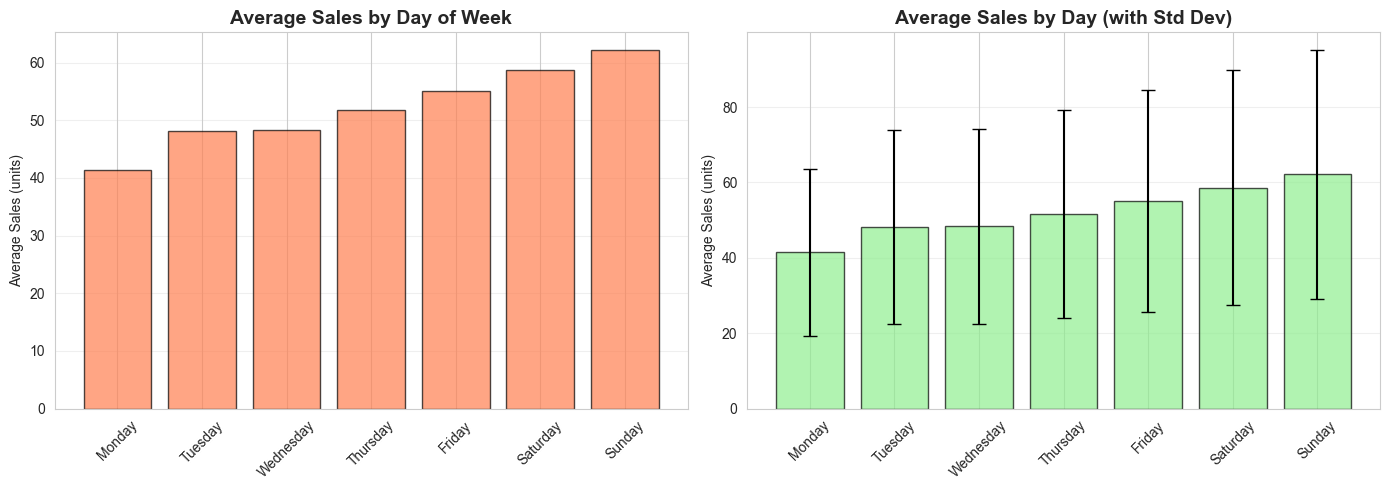


INSIGHT: Which days have highest/lowest demand? This is important for inventory planning!


In [11]:
# Average sales by day of week
sales_by_day = df_train.groupby('day_name')['sales'].agg(['mean', 'std', 'count'])

# Reorder to Monday-Sunday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = sales_by_day.reindex(day_order)

print("SALES BY DAY OF WEEK:")
print(sales_by_day)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(range(7), sales_by_day['mean'], color='coral', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_order, rotation=45)
axes[0].set_title('Average Sales by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Sales (units)')
axes[0].grid(axis='y', alpha=0.3)

# With error bars (std dev)
axes[1].bar(range(7), sales_by_day['mean'], yerr=sales_by_day['std'], 
            color='lightgreen', alpha=0.7, edgecolor='black', capsize=5)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_order, rotation=45)
axes[1].set_title('Average Sales by Day (with Std Dev)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Sales (units)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINSIGHT: Which days have highest/lowest demand? This is important for inventory planning!")

---
## STEP 8: Monthly Seasonality

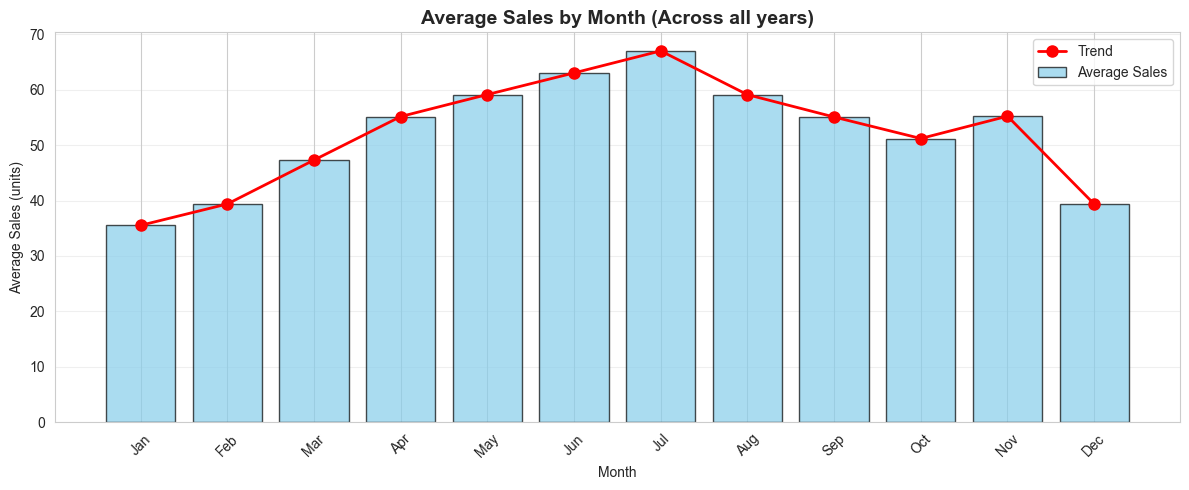

INSIGHT: Are there specific months with higher/lower sales? (e.g., holidays, seasons?)


In [12]:
# Average sales by month
sales_by_month = df_train.groupby('month')['sales'].agg(['mean', 'std'])

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 5))
plt.bar(range(1, 13), sales_by_month['mean'], color='skyblue', alpha=0.7, edgecolor='black', label='Average Sales')
plt.plot(range(1, 13), sales_by_month['mean'], color='red', marker='o', linewidth=2, markersize=8, label='Trend')
plt.xticks(range(1, 13), month_names, rotation=45)
plt.title('Average Sales by Month (Across all years)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Sales (units)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("INSIGHT: Are there specific months with higher/lower sales? (e.g., holidays, seasons?)")

---
## STEP 9: Store-wise Analysis

SALES STATISTICS BY STORE:
        mean    std  min  max  count
store                               
1      47.27  24.01    1  155  91300
2      67.03  33.60    3  231  91300
3      59.53  29.97    3  196  91300
4      54.90  27.73    4  186  91300
5      39.77  20.37    2  130  91300
6      39.73  20.31    0  134  91300
7      36.36  18.68    1  122  91300
8      64.14  32.23    4  204  91300
9      55.05  27.83    4  195  91300
10     58.71  29.55    3  187  91300


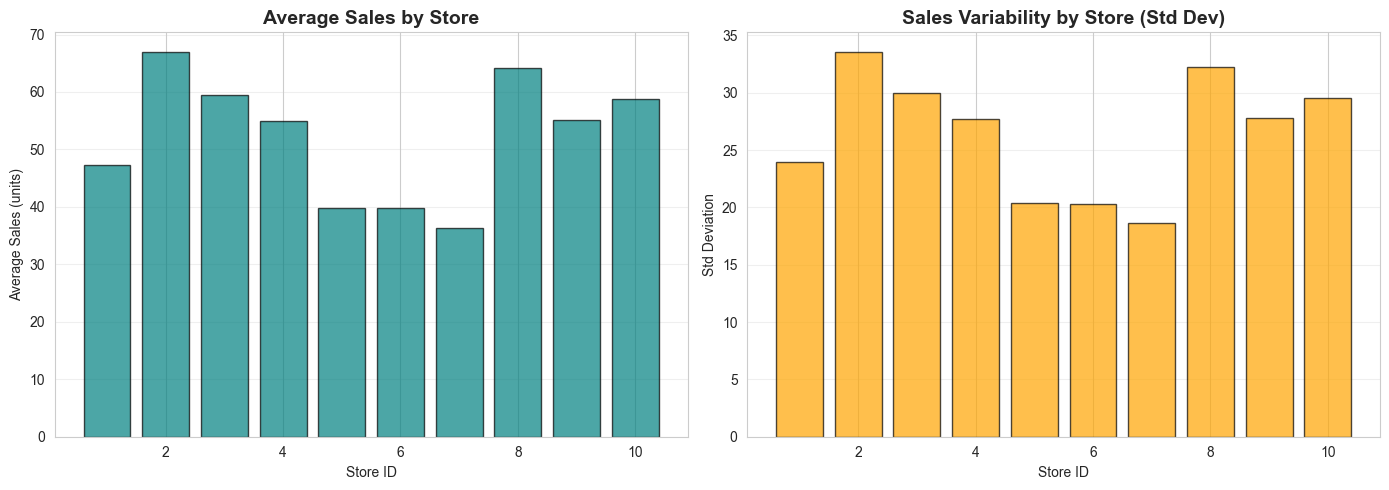


INSIGHT: Some stores have higher/lower demand. This affects waste prediction!


In [13]:
# Sales statistics by store
store_stats = df_train.groupby('store')['sales'].agg(['mean', 'std', 'min', 'max', 'count']).round(2)

print("SALES STATISTICS BY STORE:")
print(store_stats)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average sales by store
store_avg = df_train.groupby('store')['sales'].mean()
axes[0].bar(store_avg.index, store_avg.values, color='teal', alpha=0.7, edgecolor='black')
axes[0].set_title('Average Sales by Store', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Store ID')
axes[0].set_ylabel('Average Sales (units)')
axes[0].grid(axis='y', alpha=0.3)

# Variation (std dev) by store
store_std = df_train.groupby('store')['sales'].std()
axes[1].bar(store_std.index, store_std.values, color='orange', alpha=0.7, edgecolor='black')
axes[1].set_title('Sales Variability by Store (Std Dev)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Store ID')
axes[1].set_ylabel('Std Deviation')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINSIGHT: Some stores have higher/lower demand. This affects waste prediction!")

---
## STEP 10: Item-wise Analysis

TOP 10 ITEMS BY AVERAGE SALES:
           mean        std  min  max
item                                
15    88.030778  29.522852   17  231
28    87.881325  29.501781   16  206
13    84.316594  28.311031   20  210
18    84.275794  28.430621   18  208
25    80.686418  27.238817   18  193
45    80.584173  27.318402   18  205
38    80.521906  27.141799   15  188
22    80.502245  27.118163   14  214
36    77.028916  26.067440   16  188
8     76.950055  26.130697   15  181

BOTTOM 10 ITEMS (Lowest sales):
           mean        std  min  max
item                                
37    29.258379  10.771547    3   74
40    29.249398  10.822959    3   74
34    25.735761   9.617910    2   79
16    25.656079   9.603270    2   70
27    22.049726   8.461641    1   59
4     22.010241   8.403898    0   66
47    22.003341   8.420102    2   61
41    22.002136   8.402470    2   60
1     21.981599   8.468922    1   59
5     18.358708   7.265167    1   50


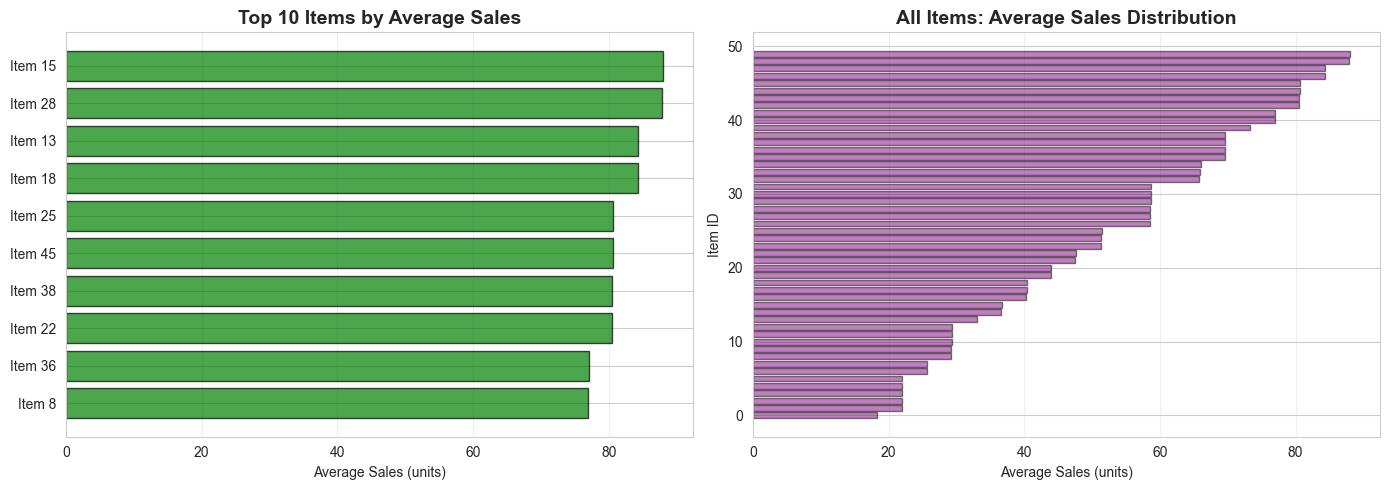


INSIGHT: Popular items need more accurate forecasting to avoid stockouts & waste.


In [14]:
# Top 10 items by average sales
item_stats = df_train.groupby('item')['sales'].agg(['mean', 'std', 'min', 'max']).sort_values('mean', ascending=False)

print("TOP 10 ITEMS BY AVERAGE SALES:")
print(item_stats.head(10))

print("\nBOTTOM 10 ITEMS (Lowest sales):")
print(item_stats.tail(10))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 items
top_items = item_stats.head(10)['mean']
axes[0].barh(range(len(top_items)), top_items.values, color='green', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(top_items)))
axes[0].set_yticklabels([f"Item {i}" for i in top_items.index])
axes[0].set_title('Top 10 Items by Average Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Sales (units)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# All items distribution
all_item_avg = df_train.groupby('item')['sales'].mean().sort_values()
axes[1].barh(range(len(all_item_avg)), all_item_avg.values, color='purple', alpha=0.5, edgecolor='black')
axes[1].set_title('All Items: Average Sales Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Sales (units)')
axes[1].set_ylabel('Item ID')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINSIGHT: Popular items need more accurate forecasting to avoid stockouts & waste.")

---
## STEP 11: Store × Item Interaction

Average Sales: Rows=Items, Columns=Stores
store          1          2          3          4          5
item                                                        
1      19.971522  28.173604  25.070099  22.938664  16.739321
2      53.148959  75.316539  66.804491  61.715225  44.488499
3      33.208105  46.992333  41.771084  38.548193  27.835706
4      19.956188  28.234940  25.116101  23.086528  16.776561
5      16.612815  23.540526  20.857612  19.525192  14.086528
6      53.060789  74.945235  67.007119  61.270537  44.564622
7      52.783680  75.058598  66.647864  61.625411  44.535597
8      69.472070  99.090361  87.517525  80.819825  58.565717
9      46.504929  65.478094  58.486857  54.043812  38.837349
10     66.354326  94.097481  83.387733  77.047645  55.509858


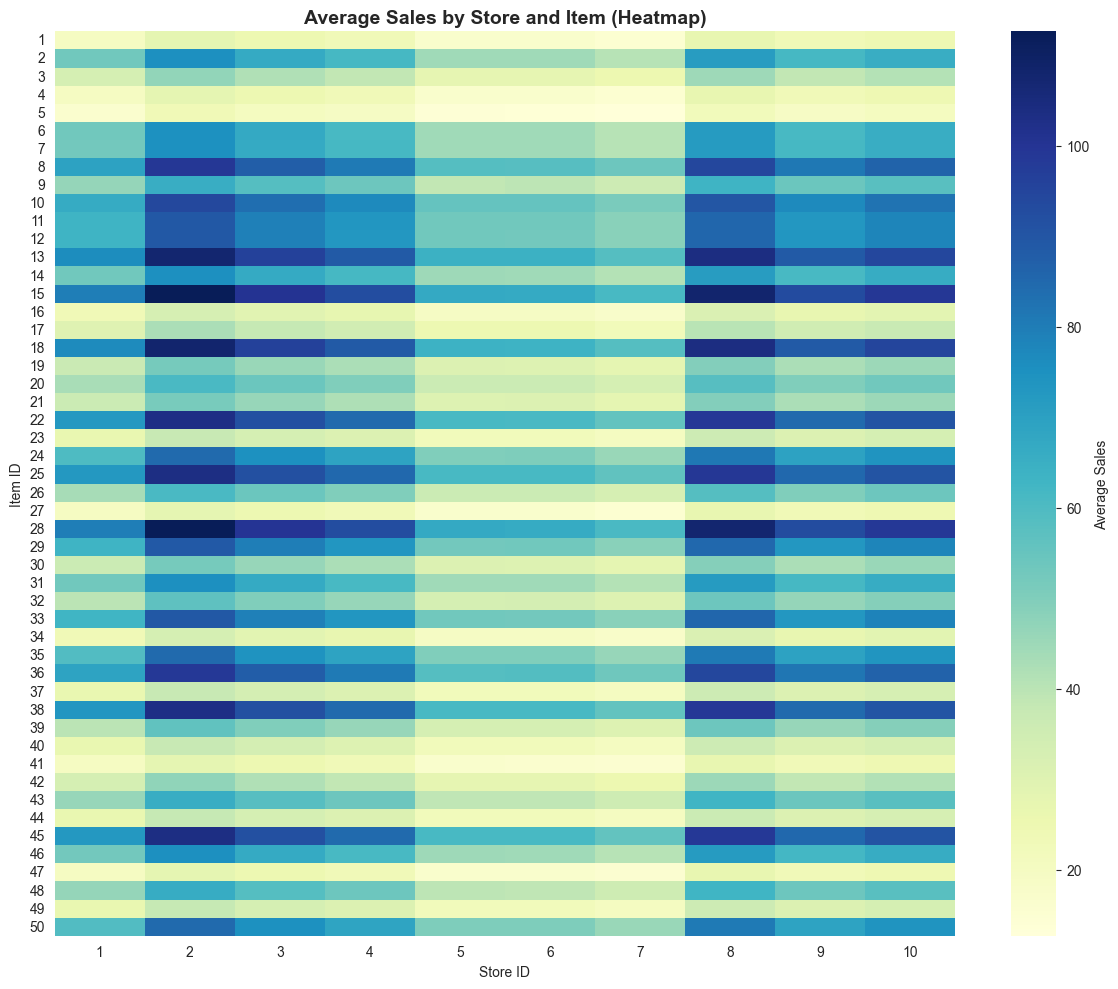


INSIGHT: Some items sell well in certain stores but not others. Localization matters!


In [15]:
# Create a pivot table: average sales for each store-item combination
pivot_sales = df_train.pivot_table(values='sales', index='item', columns='store', aggfunc='mean')

print("Average Sales: Rows=Items, Columns=Stores")
print(pivot_sales.iloc[:10, :5])  # Show first 10 items, 5 stores

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_sales, cmap='YlGnBu', cbar_kws={'label': 'Average Sales'}, annot=False)
plt.title('Average Sales by Store and Item (Heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Store ID')
plt.ylabel('Item ID')
plt.tight_layout()
plt.show()

print("\nINSIGHT: Some items sell well in certain stores but not others. Localization matters!")

---
## STEP 12: Year-over-Year Trend

YEARLY SALES SUMMARY:
           mean       sum   count
year                             
2013  43.513660   7941243  182500
2014  50.057436   9135482  182500
2015  52.256915   9536887  182500
2016  56.596503  10357160  183000
2017  58.815014  10733740  182500


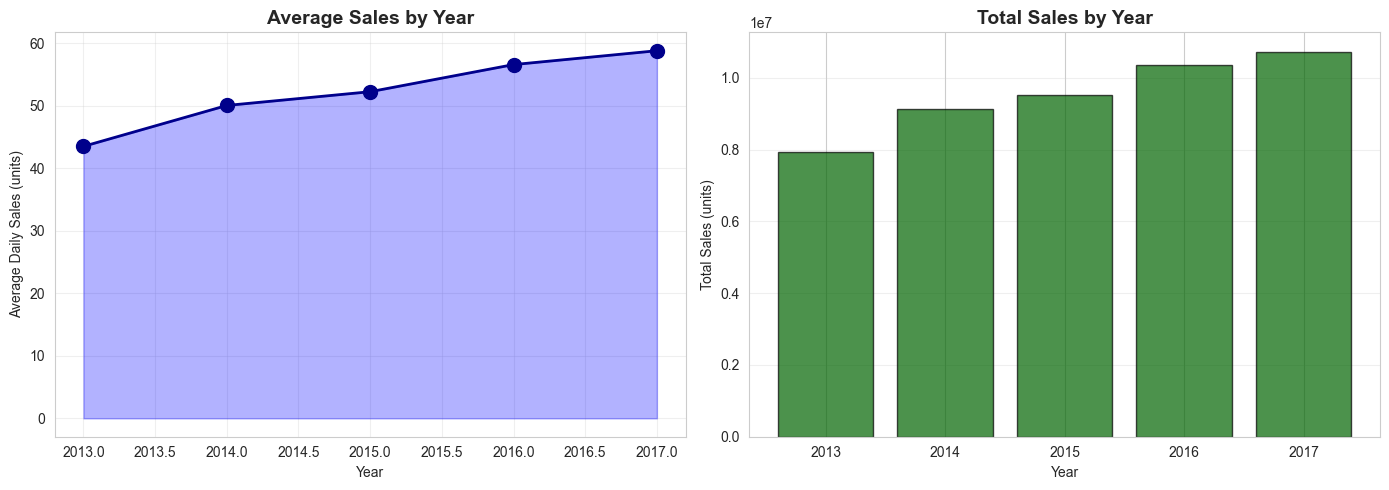


INSIGHT: Is there growth? Decline? This helps estimate future demand.


In [16]:
# Average sales by year
yearly_sales = df_train.groupby('year')['sales'].agg(['mean', 'sum', 'count'])

print("YEARLY SALES SUMMARY:")
print(yearly_sales)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average sales per year
axes[0].plot(yearly_sales.index, yearly_sales['mean'], marker='o', linewidth=2, markersize=10, color='darkblue')
axes[0].fill_between(yearly_sales.index, yearly_sales['mean'], alpha=0.3, color='blue')
axes[0].set_title('Average Sales by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Daily Sales (units)')
axes[0].grid(True, alpha=0.3)

# Total sales per year
axes[1].bar(yearly_sales.index, yearly_sales['sum'], color='darkgreen', alpha=0.7, edgecolor='black')
axes[1].set_title('Total Sales by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Sales (units)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINSIGHT: Is there growth? Decline? This helps estimate future demand.")

---
## STEP 13: Volatility & Outliers

Outlier Detection (IQR Method):
Q1: 30.0, Q3: 70.0, IQR: 40.0
Lower bound: -30.00, Upper bound: 130.00

Total outliers: 11967 out of 913000 records (1.31%)

Outlier examples:
            date  store  item  sales
21330 2016-05-29      2     2    139
21344 2016-06-12      2     2    131
21365 2016-07-03      2     2    138
21372 2016-07-10      2     2    134
21399 2016-08-06      2     2    136
21714 2017-06-17      2     2    150
21728 2017-07-01      2     2    131
21736 2017-07-09      2     2    135
21741 2017-07-14      2     2    131
21742 2017-07-15      2     2    137


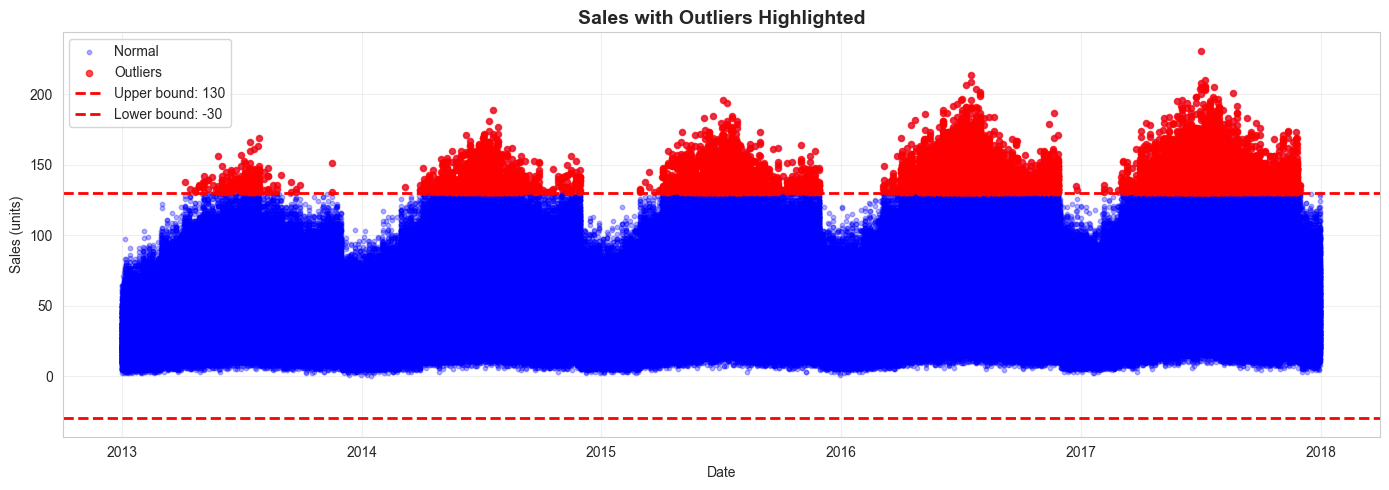


INSIGHT: Outliers could be spikes (promotions) or errors. Should we remove or keep them?


In [17]:
# Calculate outliers using IQR method
Q1 = df_train['sales'].quantile(0.25)
Q3 = df_train['sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_train[(df_train['sales'] < lower_bound) | (df_train['sales'] > upper_bound)]

print(f"Outlier Detection (IQR Method):")
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"\nTotal outliers: {len(outliers)} out of {len(df_train)} records ({len(outliers)/len(df_train)*100:.2f}%)")
print(f"\nOutlier examples:")
print(outliers[['date', 'store', 'item', 'sales']].head(10))

# Visualize outliers
plt.figure(figsize=(14, 5))
plt.scatter(df_train['date'], df_train['sales'], alpha=0.3, s=10, label='Normal', color='blue')
plt.scatter(outliers['date'], outliers['sales'], alpha=0.7, s=20, label='Outliers', color='red')
plt.axhline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper bound: {upper_bound:.0f}')
plt.axhline(lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower bound: {lower_bound:.0f}')
plt.title('Sales with Outliers Highlighted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales (units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT: Outliers could be spikes (promotions) or errors. Should we remove or keep them?")

---
## STEP 14: Correlation & Feature Relationships

CORRELATION WITH SALES:
sales        1.000000
dayofweek    0.222608
quarter      0.093867
month        0.087414
week         0.084745
store       -0.008170
item        -0.055998
Name: sales, dtype: float64


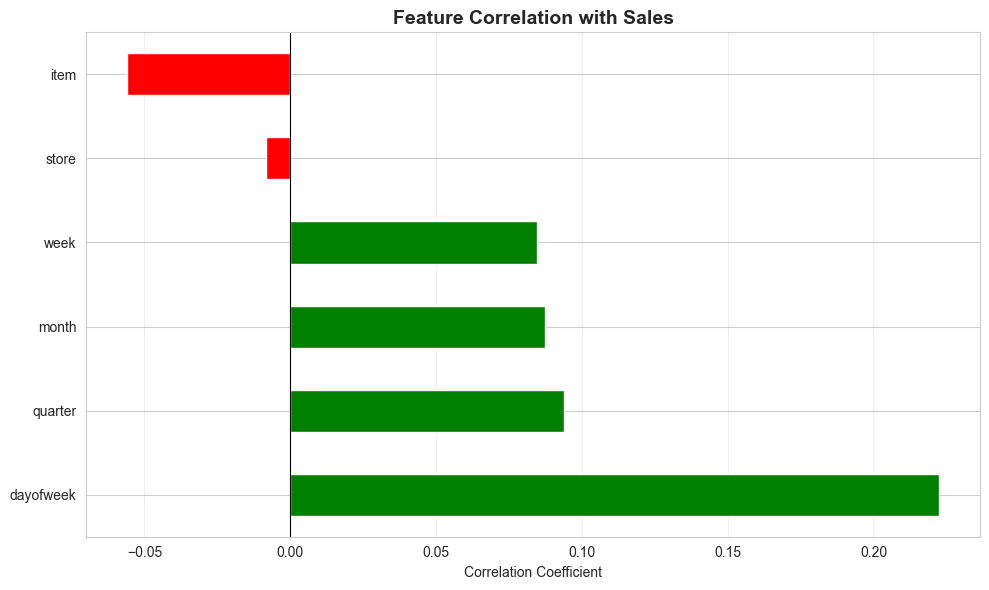


INSIGHT: Which features have the strongest relationship with sales?


In [18]:
# Create a numeric feature set for correlation
df_corr = df_train[['store', 'item', 'sales', 'month', 'dayofweek', 'quarter', 'week']].copy()

# Calculate correlation with sales
correlation = df_corr.corr()['sales'].sort_values(ascending=False)

print("CORRELATION WITH SALES:")
print(correlation)

# Visualize
plt.figure(figsize=(10, 6))
correlation.drop('sales').plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlation.drop('sales').values])
plt.title('Feature Correlation with Sales', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT: Which features have the strongest relationship with sales?")

---
## STEP 15: Summary & Key Findings

In [20]:
# Save cleaned data for modeling
df_train.to_csv('../data/train_processed.csv', index=False)
print("✓ Processed data saved to data/train_processed.csv")
print("\nReady for modeling phase!")

✓ Processed data saved to data/train_processed.csv

Ready for modeling phase!
